# **Import Libraries and Device Setup**

In [3]:
import pandas as pd
import numpy as np
import torch
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import io, ast
from transformers import CLIPProcessor, CLIPModel
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from scipy.spatial.distance import cosine
from IPython.display import display
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


# **Loading Dataset**


In [4]:
dataset_path = '/kaggle/input/pokemon-llava-images-and-text-descriptions/train.csv'

if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
    print("Loaded dataset from working directory.")

df.head()


Loaded dataset from working directory.


,image,text
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,A cartoon drawing of a green Pokemon with a le...
1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,A cartoon character with a red face and a gree...
2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,A cartoon character with a red face and white ...
3,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,A white and pink cartoon character with a smil...
4,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,A group of cartoon characters with different e...


# **Load CLIP Model & Processor**

In [5]:
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
print("CLIP model loaded.")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP model loaded.


# **Convert Byte Strings to Images**

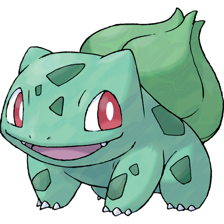

In [6]:
def convert_bytes_to_Image(byte_array):
    PIL_image = Image.open(io.BytesIO(ast.literal_eval(byte_array)['bytes']))
    PIL_image = PIL_image.resize((224, 224))
    return PIL_image

# Example display
img = convert_bytes_to_Image(df['image'].iloc[0])
display(img)


# **Split Dataset**

In [7]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))


Train size: 583
Validation size: 125
Test size: 125


# **Custom PyTorch Dataset for CLIP (Image–Text Pairs)**

In [8]:
class PokemonDataset(Dataset):
    def __init__(self, df, processor):
        self.df = df.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = convert_bytes_to_Image(row['image'])
        text = row['text']
        inputs = self.processor(
            text=[text], images=image, return_tensors="pt", padding=True
        )
        inputs["index"] = torch.tensor(idx)  # store index for metrics
        return {k: v.squeeze(0) for k, v in inputs.items()}

train_dataset = PokemonDataset(train_df, processor)
val_dataset   = PokemonDataset(val_df, processor)
test_dataset  = PokemonDataset(test_df, processor)


# **DataLoader with Custom Collate Function**

In [9]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    input_ids = [item['input_ids'] for item in batch]
    attention_mask = [item['attention_mask'] for item in batch]
    indices = [item['index'] for item in batch]

    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=processor.tokenizer.pad_token_id)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0)

    return {'pixel_values': pixel_values, 'input_ids': input_ids, 
            'attention_mask': attention_mask, 'index': torch.stack(indices)}

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

print("DataLoaders ready. Example batch shapes:")
example_batch = next(iter(train_loader))
print({k: v.shape for k, v in example_batch.items()})


DataLoaders ready. Example batch shapes:
{'pixel_values': torch.Size([16, 3, 224, 224]), 'input_ids': torch.Size([16, 19]), 'attention_mask': torch.Size([16, 19]), 'index': torch.Size([16])}


# **Fine-Tuning CLIP with Contrastive Learning**

In [10]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
epochs = 3

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        optimizer.zero_grad()
        batch = {k: v.to(device) for k, v in batch.items() if k != "index"}

        image_features = model.get_image_features(batch['pixel_values'])
        text_features = model.get_text_features(batch['input_ids'], attention_mask=batch['attention_mask'])

        image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)

        logits = image_features @ text_features.t()
        labels = torch.arange(logits.size(0), device=device)
        loss_i2t = torch.nn.CrossEntropyLoss()(logits, labels)
        loss_t2i = torch.nn.CrossEntropyLoss()(logits.t(), labels)
        loss = (loss_i2t + loss_t2i) / 2

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {running_loss / len(train_loader):.4f}")

# Save fine-tuned model
model.save_pretrained("/kaggle/working/clip-pokemon-finetuned")
processor.save_pretrained("/kaggle/working/clip-pokemon-finetuned")
print("Fine-tuned CLIP model saved.")


Training Epoch 1: 100%|██████████| 37/37 [00:35<00:00,  1.04it/s]


Epoch 1 Loss: 2.4056


Training Epoch 2: 100%|██████████| 37/37 [00:32<00:00,  1.14it/s]


Epoch 2 Loss: 2.1357


Training Epoch 3: 100%|██████████| 37/37 [00:31<00:00,  1.16it/s]


Epoch 3 Loss: 2.0479
Fine-tuned CLIP model saved.


# **Compute Image Embeddings for Retrieval**

In [11]:
def get_image_embeddings(model, dataset, batch_size=32):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    all_embeddings, all_indices = [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            pixel_values = batch['pixel_values'].to(device)
            feats = model.get_image_features(pixel_values)
            feats = feats / feats.norm(dim=-1, keepdim=True)
            all_embeddings.append(feats.cpu())
            all_indices.extend(batch["index"].tolist())

    return torch.cat(all_embeddings), all_indices

val_embeddings, _  = get_image_embeddings(model, val_dataset)
test_embeddings, _ = get_image_embeddings(model, test_dataset)
print("Embeddings shapes:", val_embeddings.shape, test_embeddings.shape)


Embeddings shapes: torch.Size([125, 512]) torch.Size([125, 512])


# **Encode Query and Compute Similarity**

In [12]:
def encode_query(model, processor, query):
    inputs = processor(text=[query], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_emb = model.get_text_features(**inputs)
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
    return text_emb

def compute_similarity(text_emb, image_emb, method="cosine"):
    if method == "cosine":
        return (text_emb @ image_emb.T).squeeze(0)
    elif method == "dot":
        return (text_emb * image_emb).sum(dim=-1)
    elif method == "euclidean":
        # Negative distance (so higher = more similar)
        dists = torch.cdist(text_emb, image_emb)  
        return -dists.squeeze(0)
    else:
        raise ValueError("Unknown similarity method")


# **Retrieve Image Function**

In [13]:
def retrieve_images(query, model, processor, image_embeddings, dataset, top_k=5, method="cosine"):
    text_emb = encode_query(model, processor, query).to(device)
    image_embeddings = image_embeddings.to(device)
    sims = compute_similarity(text_emb, image_embeddings, method)
    topk_scores, topk_indices = sims.topk(top_k)

    print(f"\n🔎 Query: '{query}' ({method} similarity)")
    captions, scores = [], []

    for rank, (idx_tensor, score) in enumerate(zip(topk_indices, topk_scores)):
        idx = idx_tensor.item()
        row = dataset.df.iloc[idx]
        captions.append(row['text'])
        scores.append(score.item())
        print(f"Rank {rank+1}: {row['text']} (score={score.item():.4f})")
        img = convert_bytes_to_Image(row['image'])
        display(img)

    # Plot scores
    plt.figure(figsize=(8,4))
    plt.barh(range(top_k-1, -1, -1), scores, color='lightgreen')
    plt.yticks(range(top_k-1, -1, -1), captions)
    plt.xlabel("Similarity Score")
    plt.title(f"Top-{top_k} results ({method})")
    plt.show()


# Ranking-based Evaluation Metrics

In [16]:
@torch.no_grad()
def get_text_embeddings(model, dataset, batch_size=32):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    all_embeddings = []
    model.eval()
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        feats = model.get_text_features(input_ids=input_ids, attention_mask=attention_mask)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        all_embeddings.append(feats.cpu())
    return torch.cat(all_embeddings, dim=0)

def similarity_matrix(text_embs: torch.Tensor,
                      image_embs: torch.Tensor,
                      method: str = "cosine") -> torch.Tensor:
    """
    Returns sims of shape [num_text, num_images]; higher is better.
    Assumes both inputs are already L2-normalized for cosine/dot.
    """
    text_embs = text_embs.to(device)
    image_embs = image_embs.to(device)

    if method in ("cosine", "dot"):
        return text_embs @ image_embs.T
    elif method == "euclidean":
        d = torch.cdist(text_embs, image_embs)  # lower distance = better
        return -d
    else:
        raise ValueError(f"Unknown method: {method}")

def evaluate_ranking(text_embs: torch.Tensor,
                     image_embs: torch.Tensor,
                     Ks=(1, 5, 10),
                     method: str = "cosine") -> dict:
    """
    Computes ranking metrics for text->image retrieval (1 relevant per query).
    Metrics: Hit@K (Recall@K), MRR, Mean/Median Rank, NDCG@K.
    """
    sims = similarity_matrix(text_embs, image_embs, method=method)  # [T, I]
    sims_np = sims.detach().cpu().numpy()
    num_q = sims_np.shape[0]

    ranks = []
    for i in range(num_q):
        order = np.argsort(-sims_np[i])  # descending
        rank = int(np.where(order == i)[0][0]) + 1  # 1-based
        ranks.append(rank)

    ranks = np.array(ranks)

    metrics = {}
    for K in Ks:
        metrics[f"Hit@{K}"] = float(np.mean(ranks <= K))

    metrics["MRR"] = float(np.mean(1.0 / ranks))
    metrics["MeanRank"] = float(np.mean(ranks))
    metrics["MedianRank"] = float(np.median(ranks))

    for K in Ks:
        gains = np.where(ranks <= K, 1.0 / np.log2(ranks + 1), 0.0)
        metrics[f"NDCG@{K}"] = float(np.mean(gains))

    return metrics


# **Compare Metrics Across Val/Test for Similarity Methods**

In [17]:
similarity_methods = ["cosine", "dot", "euclidean"]

val_text_embs  = get_text_embeddings(model, val_dataset)
test_text_embs = get_text_embeddings(model, test_dataset)

results_comparison = {}
Ks = (1, 5, 10)

for method in similarity_methods:
    print(f"\n=== Evaluating with {method} similarity ===")
    val_metrics  = evaluate_ranking(val_text_embs,  val_embeddings,  Ks=Ks, method=method)
    test_metrics = evaluate_ranking(test_text_embs, test_embeddings, Ks=Ks, method=method)

    results_comparison[method] = {
        "Validation": {k: (round(v, 3) if isinstance(v, float) else v) for k, v in val_metrics.items()},
        "Test":       {k: (round(v, 3) if isinstance(v, float) else v) for k, v in test_metrics.items()},
    }

df_results = pd.DataFrame({
    (method, split): metrics
    for method, splits in results_comparison.items()
    for split, metrics in splits.items()
})

print("\n📊 Final Ranking Metrics:")
display(df_results)



=== Evaluating with cosine similarity ===

=== Evaluating with dot similarity ===

=== Evaluating with euclidean similarity ===

📊 Final Ranking Metrics:


cosine               dot         euclidean       
           Validation   Test Validation   Test Validation   Test
Hit@1           0.320  0.344      0.320  0.344      0.320  0.344
Hit@5           0.600  0.672      0.600  0.672      0.600  0.672
Hit@10          0.704  0.792      0.704  0.792      0.704  0.792
MRR             0.454  0.479      0.454  0.479      0.454  0.479
MeanRank        9.248  9.464      9.248  9.464      9.248  9.464
MedianRank      4.000  3.000      4.000  3.000      4.000  3.000
NDCG@1          0.320  0.344      0.320  0.344      0.320  0.344
NDCG@5          0.467  0.507      0.467  0.507      0.467  0.507
NDCG@10         0.502  0.547      0.502  0.547      0.502  0.547

# **Visualization**

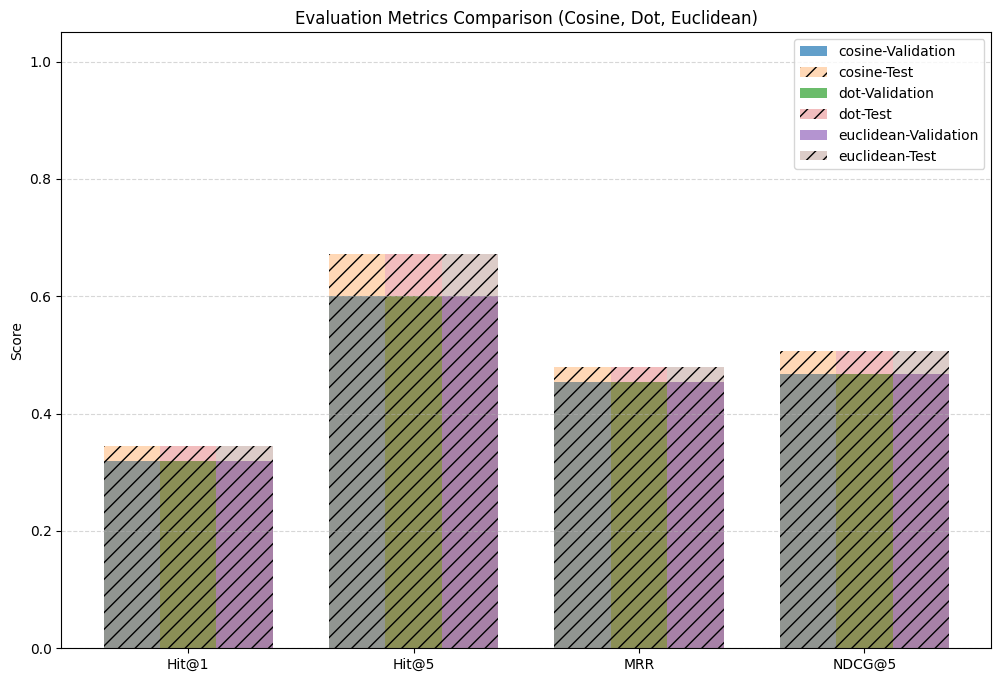

In [23]:
# Metrics we want to plot
plot_metrics = [f"Hit@{Ks[0]}", f"Hit@{Ks[1]}", "MRR", f"NDCG@{Ks[1]}"]
x = np.arange(len(plot_metrics))
width = 0.25  # Adjusted width to fit 3 bars for each metric

# Offsets for each method to ensure the bars don't overlap
offsets = {
    "cosine": -width,
    "dot": 0,
    "euclidean": width
}

# Create the bar plots for each similarity method and split (Validation/Test)
plt.figure(figsize=(12, 8))
for method in ["cosine", "dot", "euclidean"]:
    # Extract values for both validation and test sets
    val_vals = [results_comparison[method]["Validation"][m] for m in plot_metrics]
    test_vals = [results_comparison[method]["Test"][m] for m in plot_metrics]

    # Plot the validation and test data side by side for each method
    plt.bar(x + offsets[method], val_vals, width, label=f"{method}-Validation", alpha=0.7)
    plt.bar(x + offsets[method], test_vals, width, label=f"{method}-Test", alpha=0.3, hatch="//")

# Customizing the plot
plt.xticks(x, plot_metrics)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Evaluation Metrics Comparison (Cosine, Dot, Euclidean)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.show()


# **Retrieve Image**

=== Validation Set ===

🔎 Query: 'a pokemon with a green and smiling face' (cosine similarity)
Rank 1: A cartoon drawing of a green dinosaur with a long tail and a yellow flower in its mouth. (score=0.9413)


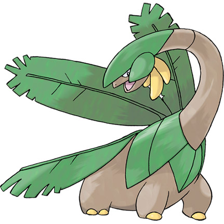

Rank 2: A cartoon character wearing a green hat and green clothing. (score=0.9316)


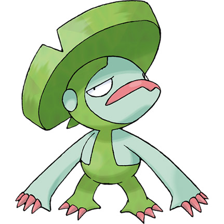

Rank 3: A cartoon drawing of a green insect with a leaf for a head. (score=0.9304)


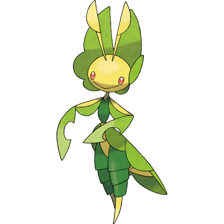

Rank 4: A cartoon drawing of an alien with a green head and a big green eye. (score=0.9204)


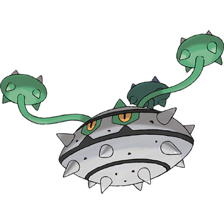

Rank 5: A green cartoon character with a red belt and yellow dots on its neck. (score=0.9094)


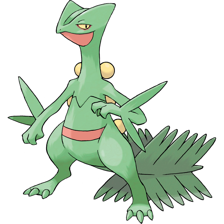

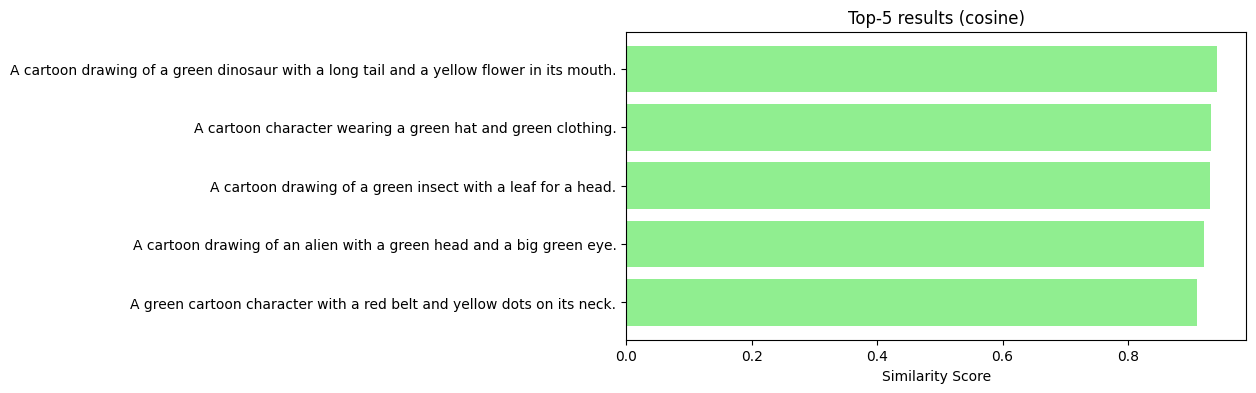

=== Test Set ===

🔎 Query: 'a pokemon with a green and smiling face' (cosine similarity)
Rank 1: A cartoon character with a green leaf on its head. (score=0.9429)


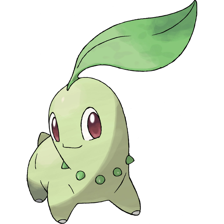

Rank 2: A cartoon drawing of a green and black creature with a leafy green top and white flowers. (score=0.9324)


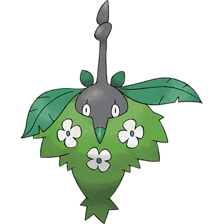

Rank 3: A green and white stuffed toy with a green hat and green eyes. (score=0.9192)


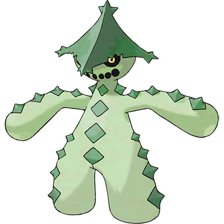

Rank 4: A green dragon with a sword in its hand. (score=0.8979)


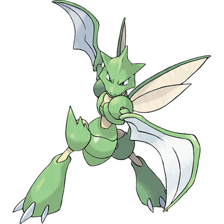

Rank 5: A cartoon character with a red tongue and a pink nose. (score=0.8844)


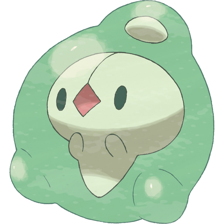

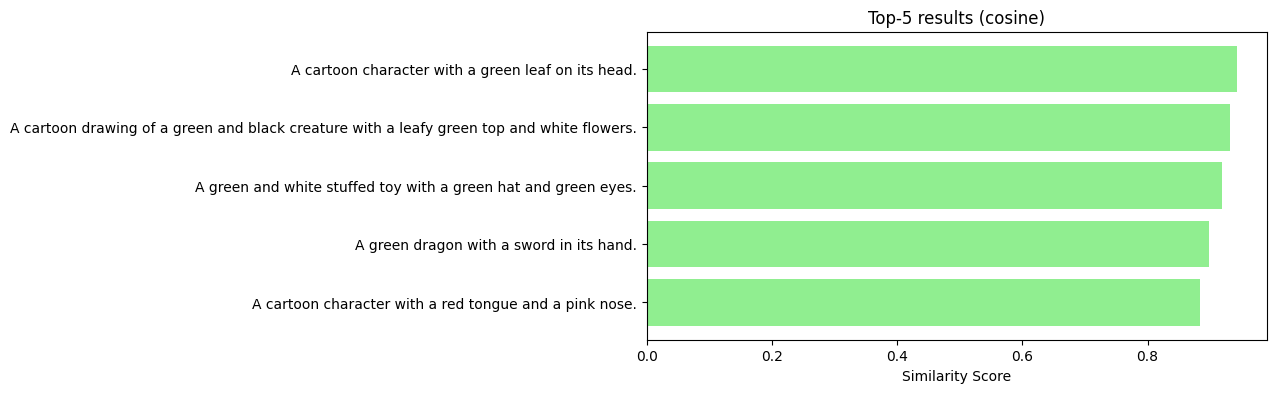

In [22]:
query = "a pokemon with a green and smiling face"

# Retrieve images from the Validation set
print("=== Validation Set ===")
retrieve_images(query, model, processor, val_embeddings, val_dataset, top_k=5, method="cosine")

# Retrieve images from the Test set
print("=== Test Set ===")
retrieve_images(query, model, processor, test_embeddings, test_dataset, top_k=5, method="cosine")
